In [ ]:
# JAX Jit Deep Dive Part 3: Operator Fusion Analysis
import torch 
from torch import jit
from torch.profiler import profile, ProfilerActivity, record_function

def summation_EagerMode(x):
    result = torch.zeros_like(x)
    for i in range(1, 101):
        sinVal = x
        cosVal = x
        for _ in range(i):
            sinVal = torch.sin(sinVal)
            cosVal = torch.cos(cosVal)
        
        result += sinVal + cosVal
    return result

@jit.script
def summation_Jit(x):
    result = torch.zeros_like(x)
    sinVal = x
    cosVal = x

    for _ in range(100):
        sinVal = torch.sin(sinVal)
        cosVal = torch.cos(cosVal)
        result += sinVal + cosVal
    return result

x = torch.randn(8192, 8192, device='cuda')

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack = True
) as profEager:
    summation_EagerMode(x)

summary_eager = profEager.key_averages().table(sort_by='cuda_time_total', row_limit=10)
print("Eager Execution Profile")
print(summary_eager)

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack = True
) as profJit:
    summation_Jit(x)
summary_jit = profJit.key_averages().table(sort_by='cuda_time_total', row_limit=10)
print("Jit Execution Profile")
print(summary_jit)

Eager Execution Profile
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us        4.165s        48.85%        4.165s     824.763us          5050  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us        4.097s        48.05%        4.097s     811.344us  

0.9.1
[CudaDevice(id=0)]
gpu
Shape:  (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=computeMeanOfMatrix
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape:  (100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = jit[
      name=computeMeanOfMatrix
      jaxpr={ lambda ; a:f32[100,200]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 200.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape:  (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=computeMeanOfMatrix
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape:  (200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = jit[
      name=computeMeanOfMatri

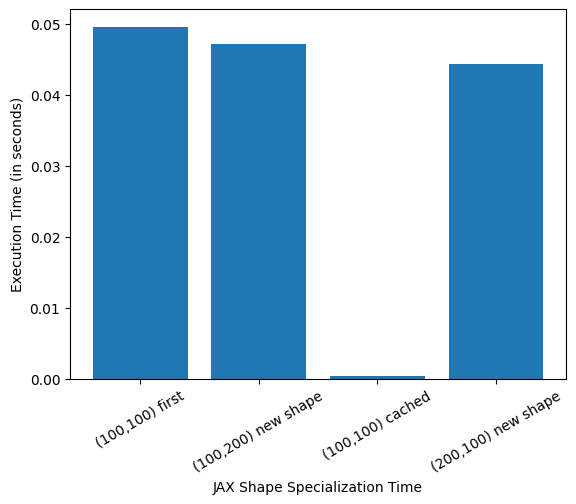

In [73]:
# JAX Jit Deep Dive Part 2: Shape Specialization
import jax 
import jax.numpy 
import numpy
import time
import matplotlib.pyplot as plt

print(jax.__version__)
print(jax.devices())
print(jax.default_backend())

@jax.jit
def computeMeanOfMatrix(x):
    return jax.numpy.mean(x, axis=1)

A = jax.numpy.array(numpy.random.rand(100,100))
print("Shape: ", A.shape)
print(jax.make_jaxpr(computeMeanOfMatrix)(A))

B = jax.numpy.array(numpy.random.rand(100,200))
print("Shape: ", B.shape)
print(jax.make_jaxpr(computeMeanOfMatrix)(B))

print("Shape: ", A.shape)
print(jax.make_jaxpr(computeMeanOfMatrix)(A))

C = jax.numpy.array(numpy.random.rand(200,100))
print("Shape: ", C.shape)
print(jax.make_jaxpr(computeMeanOfMatrix)(C))

times = []
labels = []
start = time.perf_counter()
computeMeanOfMatrix(A).block_until_ready()
times.append(time.perf_counter() - start)
labels.append("(100,100) first")

start = time.perf_counter()
computeMeanOfMatrix(B).block_until_ready()
times.append(time.perf_counter() - start)
labels.append("(100,200) new shape")

start = time.perf_counter()
computeMeanOfMatrix(A).block_until_ready()
times.append(time.perf_counter() - start)
labels.append("(100,100) cached")

start = time.perf_counter()
computeMeanOfMatrix(C).block_until_ready()
times.append(time.perf_counter() - start)
labels.append("(200,100) new shape")

plt.bar(labels, times)
plt.ylabel("Execution Time (in seconds)")
plt.xlabel("JAX Shape Specialization Time")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# JAX JIT Deep Dive Part 1: Measuring Compilation Overhead Question 3
# Execution Time: Second call with @jit (cached compilation)

import torch
import time

def elementWiseOp(x):
    x = torch.sin(x)
    x = torch.cos(x)
    x = torch.exp(x)
    x = torch.log(torch.abs(x) + 5)
    x = x ** 8
    x = torch.sqrt(x * 2)
    x = torch.tanh(x)
    x = torch.cosh(x)
    x = torch.relu(x)
    x = torch.sinh(x)
    return x

matrix = torch.rand(10000, 10000, device="cuda")

compiledFunction = torch.compile(elementWiseOp)

torch.cuda.synchronize()
start = time.perf_counter()

y = compiledFunction(matrix)

torch.cuda.synchronize()
end = time.perf_counter()
print("Exec Time of Second Call with @jit (including compilation): ", end-start, " seconds")

Exec Time of Second Call with @jit (including compilation):  0.11687070699917967  seconds


In [ ]:
# JAX JIT Deep Dive Part 1: Measuring Compilation Overhead Question 2
# Execution Time: First call with @jit (including compilation)

import torch
import time

def elementWiseOp(x):
    x = torch.sin(x)
    x = torch.cos(x)
    x = torch.exp(x)
    x = torch.log(torch.abs(x) + 5)
    x = x ** 8
    x = torch.sqrt(x * 2)
    x = torch.tanh(x)
    x = torch.cosh(x)
    x = torch.relu(x)
    x = torch.sinh(x)
    return x

matrix = torch.rand(10000, 10000, device="cuda")

compiledFunction = torch.compile(elementWiseOp)

torch.cuda.synchronize()
start = time.perf_counter()

y = compiledFunction(matrix)

torch.cuda.synchronize()
end = time.perf_counter()
print("Exec Time of First Call with @jit (including compilation): ", end-start, " seconds")

Exec Time of First Call with @jit (including compilation):  0.05745183700128109  seconds


In [ ]:
# JAX JIT Deep Dive Part 1: Measuring Compilation Overhead Question 1
# Execution Time of Eager Mode (without @jit)

import torch
import time

def doElementWiseOp(x):
    x = torch.sin(x)
    x = torch.cos(x)
    x = torch.exp(x)
    x = torch.log(torch.abs(x) + 5)
    x = x ** 8
    x = torch.sqrt(x * 2)
    x = torch.tanh(x)
    x = torch.cosh(x)
    x = torch.relu(x)
    x = torch.sinh(x)
    return x

matrix = torch.rand(10000, 10000)

torch.cuda.synchronize()
start = time.perf_counter()

y = doElementWiseOp(matrix)

torch.cuda.synchronize()
end = time.perf_counter()
print("Exec Time of Eager Mode: ", end-start, " seconds")

Exec Time of Eager Mode:  1.482686718001787  seconds


In [77]:
import torch
 
# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available!")
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Using CPU instead.")
    device = torch.device("cpu")

CUDA is available!
Using GPU: NVIDIA GeForce RTX 3090
